In [ ]:
# import os
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, LSTM, Dense
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from xgboost import XGBClassifier
# import joblib
# from tensorflow.keras.models import load_model

# class GPINTrainer:
#     def __init__(self, csv_path="gpin_data.csv", model_dir="models", seq_len=10):
#         self.csv_path = csv_path
#         self.model_dir = model_dir
#         self.seq_len = seq_len
#         os.makedirs(model_dir, exist_ok=True)

#     def preprocess_data(self):
#         df = pd.read_csv(self.csv_path)

#         # Label encoding
#         self.label_encoder = LabelEncoder()
#         df['target_encoded'] = self.label_encoder.fit_transform(df['target'])

#         # Feature extraction
#         self.feature_cols = df.drop(columns=['target', 'target_encoded']).columns.tolist()
#         X = df[self.feature_cols].values
#         y = df['target_encoded'].values

#         # Feature scaling
#         self.scaler = StandardScaler()
#         X_scaled = self.scaler.fit_transform(X)

#         # Sequence formation
#         num_sequences = len(X_scaled) // self.seq_len
#         X_seq = X_scaled[:num_sequences * self.seq_len]
#         y_seq = y[:num_sequences * self.seq_len]

#         self.X_lstm = X_seq.reshape(num_sequences, self.seq_len, len(self.feature_cols))
#         self.y_lstm = y_seq.reshape(num_sequences, self.seq_len)[:, -1]

#         # Train-test split
#         self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
#             self.X_lstm, self.y_lstm, test_size=0.2, random_state=42, stratify=self.y_lstm
#         )
#         print("✅ Data preprocessing complete.")

#     def build_lstm_model(self):
#         input_layer = Input(shape=(self.X_train.shape[1], self.X_train.shape[2]))
#         lstm_out = LSTM(64, return_sequences=False)(input_layer)
#         dense_out = Dense(32, activation='relu')(lstm_out)
#         output_layer = Dense(len(np.unique(self.y_train)), activation='softmax')(dense_out)

#         self.lstm_model = Model(inputs=input_layer, outputs=output_layer)
#         self.lstm_model.compile(optimizer=Adam(0.001),
#                                 loss='sparse_categorical_crossentropy',
#                                 metrics=['accuracy'])

#         early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#         history = self.lstm_model.fit(
#             self.X_train, self.y_train,
#             validation_split=0.2,
#             epochs=12,
#             batch_size=64,
#             callbacks=[early_stop],
#             verbose=1
#         )

#         self.lstm_model.save(os.path.join(self.model_dir, "lstm_model.h5"))
#         print("✅ LSTM model trained and saved.")

#     def train_xgboost(self):
#         # Extract dense features from trained LSTM
#         extractor = Model(inputs=self.lstm_model.input, outputs=self.lstm_model.layers[-2].output)
#         X_train_features = extractor.predict(self.X_train)
#         X_test_features = extractor.predict(self.X_test)

#         self.xgb_model = XGBClassifier(
#             n_estimators=100,
#             max_depth=6,
#             learning_rate=0.1,
#             use_label_encoder=False,
#             eval_metric='mlogloss'
#         )
#         self.xgb_model.fit(X_train_features, self.y_train)

#         # Save XGBoost model
#         joblib.dump(self.xgb_model, os.path.join(self.model_dir, "xgb_model.pkl"))
#         joblib.dump(self.scaler, os.path.join(self.model_dir, "scaler.pkl"))
#         joblib.dump(self.label_encoder, os.path.join(self.model_dir, "label_encoder.pkl"))
#         print("✅ XGBoost model trained and saved.")

#         # Evaluate
#         y_pred = self.xgb_model.predict(X_test_features)
#         print("\n🎯 Accuracy:", accuracy_score(self.y_test, y_pred))
#         print("\n📄 Classification Report:\n")
#         print(classification_report(self.y_test, y_pred, target_names=self.label_encoder.classes_))
#         print("\n📊 Confusion Matrix:\n")
#         print(confusion_matrix(self.y_test, y_pred))

#         # Sample outputs
#         true_labels = self.label_encoder.inverse_transform(self.y_test)
#         pred_labels = self.label_encoder.inverse_transform(y_pred)

#         print("\n🔍 Sample Predictions:")
#         for i in range(20):
#             print(f"{i+1:02d}) 🟢 True: {true_labels[i]:<15} | 🔵 Predicted: {pred_labels[i]}")

#     def run_pipeline(self):
#         self.preprocess_data()
#         self.build_lstm_model()
#         self.train_xgboost()

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
import joblib
from tensorflow.keras.models import load_model

class GPINTrainer:
    def __init__(self, csv_path="gpin_data.csv", model_dir="models", seq_len=10):
        self.csv_path = csv_path
        self.model_dir = model_dir
        self.seq_len = seq_len
        os.makedirs(model_dir, exist_ok=True)

    def preprocess_data(self):
        df = pd.read_csv(self.csv_path)

        self.label_encoder = LabelEncoder()
        df['target_encoded'] = self.label_encoder.fit_transform(df['target'])

        self.feature_cols = df.drop(columns=['target', 'target_encoded']).columns.tolist()
        X = df[self.feature_cols].values
        y = df['target_encoded'].values

        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)

        num_sequences = len(X_scaled) // self.seq_len
        X_seq = X_scaled[:num_sequences * self.seq_len]
        y_seq = y[:num_sequences * self.seq_len]

        self.X_lstm = X_seq.reshape(num_sequences, self.seq_len, len(self.feature_cols))
        self.y_lstm = y_seq.reshape(num_sequences, self.seq_len)[:, -1]

        X_temp, self.X_test, y_temp, self.y_test = train_test_split(
            self.X_lstm, self.y_lstm, test_size=0.2, random_state=42, stratify=self.y_lstm
        )

        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
        )

        print("✅ Data preprocessing complete.")

    def build_lstm_model(self):
        input_layer = Input(shape=(self.X_train.shape[1], self.X_train.shape[2]))
        lstm_out = LSTM(64, return_sequences=False)(input_layer)
        dense_out = Dense(32, activation='relu')(lstm_out)
        output_layer = Dense(len(np.unique(self.y_train)), activation='softmax')(dense_out)

        self.lstm_model = Model(inputs=input_layer, outputs=output_layer)
        self.lstm_model.compile(optimizer=Adam(0.001),
                                loss='sparse_categorical_crossentropy',
                                metrics=['accuracy'])

        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        self.history = self.lstm_model.fit(
            self.X_train, self.y_train,
            validation_data=(self.X_val, self.y_val),
            epochs=50,
            batch_size=64,
            callbacks=[early_stop],
            verbose=1
        )

        self.lstm_model.save(os.path.join(self.model_dir, "lstm_model.h5"))
        print("✅ LSTM model trained and saved.")

    def plot_convergence(self):
        plt.figure(figsize=(10, 4))
        plt.plot(self.history.history['accuracy'], label='Train Acc')
        plt.plot(self.history.history['val_accuracy'], label='Val Acc')
        plt.title('LSTM Accuracy Convergence')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def train_xgboost(self):
        extractor = Model(inputs=self.lstm_model.input, outputs=self.lstm_model.layers[-2].output)
        X_train_features = extractor.predict(self.X_train)
        X_test_features = extractor.predict(self.X_test)

        self.xgb_model = XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            use_label_encoder=False,
            eval_metric='mlogloss'
        )
        self.xgb_model.fit(X_train_features, self.y_train)

        joblib.dump(self.xgb_model, os.path.join(self.model_dir, "xgb_model.pkl"))
        joblib.dump(self.scaler, os.path.join(self.model_dir, "scaler.pkl"))
        joblib.dump(self.label_encoder, os.path.join(self.model_dir, "label_encoder.pkl"))
        print("✅ XGBoost model trained and saved.")

        y_pred = self.xgb_model.predict(X_test_features)

        print("\n🎯 Accuracy:", accuracy_score(self.y_test, y_pred))
        print("\n📄 Classification Report:\n")
        print(classification_report(self.y_test, y_pred, target_names=self.label_encoder.classes_))

        # Confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=self.label_encoder.classes_, yticklabels=self.label_encoder.classes_)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

        # Sample predictions
        true_labels = self.label_encoder.inverse_transform(self.y_test)
        pred_labels = self.label_encoder.inverse_transform(y_pred)

        print("\n🔍 Sample Predictions:")
        for i in range(20):
            print(f"{i+1:02d}) 🟢 True: {true_labels[i]:<15} | 🔵 Predicted: {pred_labels[i]}")

    def run_pipeline(self):
        self.preprocess_data()
        self.build_lstm_model()
        self.plot_convergence()
        self.train_xgboost()


✅ Data preprocessing complete.
Epoch 1/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7249 - loss: 0.6226 - val_accuracy: 0.9383 - val_loss: 0.2586
Epoch 2/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8404 - loss: 0.2613 - val_accuracy: 0.9380 - val_loss: 0.1152
Epoch 3/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9352 - loss: 0.1141 - val_accuracy: 0.9375 - val_loss: 0.1150
Epoch 4/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9334 - loss: 0.1162 - val_accuracy: 0.9384 - val_loss: 0.1108
Epoch 5/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9362 - loss: 0.1144 - val_accuracy: 0.9384 - val_loss: 0.1117
Epoch 6/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9134 - loss: 0.1495 - val_accuracy: 0.8318 - val_loss: 0.2608
Epoch 7/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8370 - loss: 0.2610 - val_accuracy: 0.8323 - val_loss: 0.2585
Epoch 8/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8351 - 

✅ LSTM model trained and saved.


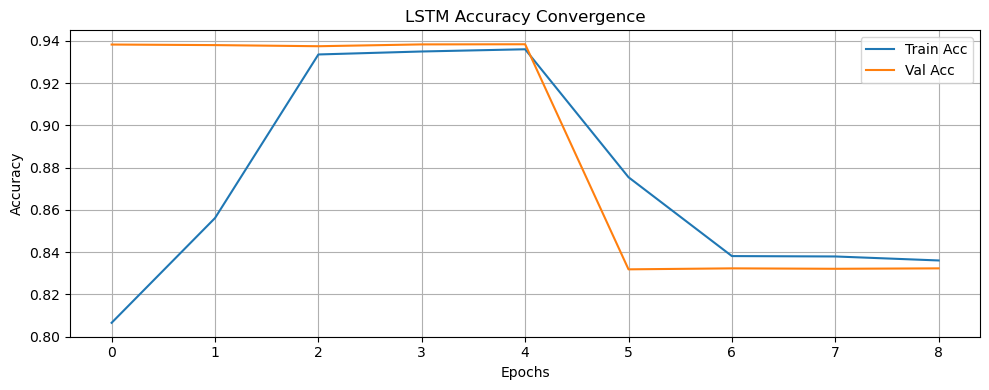

1884/1884 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
589/589 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
✅ XGBoost model trained and saved.

🎯 Accuracy: 0.9358143979613506

📄 Classification Report:

              precision    recall  f1-score   support

   ACK_FLOOD       1.00      1.00      1.00      2000
      BENIGN       1.00      1.00      1.00      4000
    IP_SPOOF       0.62      1.00      0.77      2000
     SYN_ACK       1.00      1.00      1.00      2000
   SYN_FLOOD       1.00      0.40      0.57      2000
   TCP_FLOOD       1.00      1.00      1.00      2000
   UDP_FLOOD       1.00      1.00      1.00      2000
    UDP_FRAG       1.00      1.00      1.00      1554
   UDP_PLAIN       1.00      1.00      1.00      1282

    accuracy                           0.94     18836
   macro avg       0.96      0.93      0.93     18836
weighted avg       0.96      0.94      0.93     18836



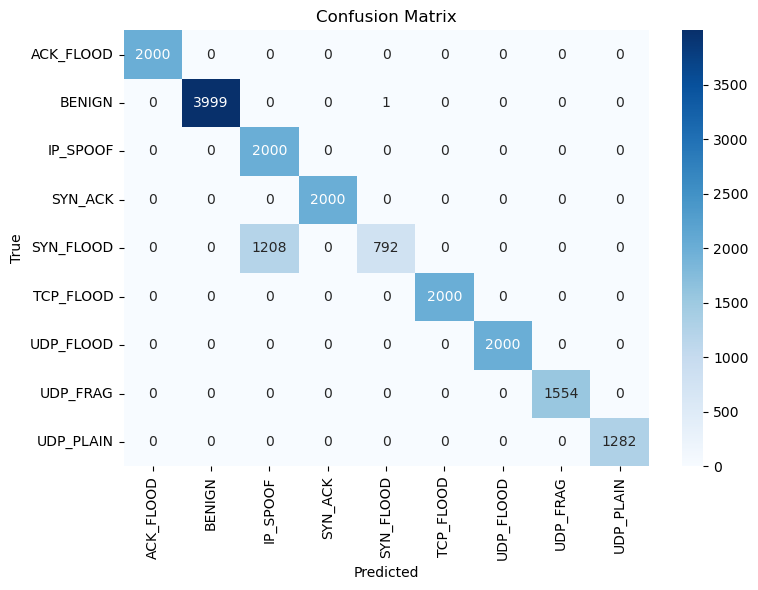


🔍 Sample Predictions:
01) 🟢 True: BENIGN          | 🔵 Predicted: BENIGN
02) 🟢 True: UDP_FLOOD       | 🔵 Predicted: UDP_FLOOD
03) 🟢 True: TCP_FLOOD       | 🔵 Predicted: TCP_FLOOD
04) 🟢 True: SYN_FLOOD       | 🔵 Predicted: SYN_FLOOD
05) 🟢 True: SYN_FLOOD       | 🔵 Predicted: IP_SPOOF
06) 🟢 True: ACK_FLOOD       | 🔵 Predicted: ACK_FLOOD
07) 🟢 True: BENIGN          | 🔵 Predicted: BENIGN
08) 🟢 True: BENIGN          | 🔵 Predicted: BENIGN
09) 🟢 True: SYN_FLOOD       | 🔵 Predicted: SYN_FLOOD
10) 🟢 True: BENIGN          | 🔵 Predicted: BENIGN
11) 🟢 True: UDP_PLAIN       | 🔵 Predicted: UDP_PLAIN
12) 🟢 True: BENIGN          | 🔵 Predicted: BENIGN
13) 🟢 True: UDP_FRAG        | 🔵 Predicted: UDP_FRAG
14) 🟢 True: SYN_ACK         | 🔵 Predicted: SYN_ACK
15) 🟢 True: SYN_FLOOD       | 🔵 Predicted: IP_SPOOF
16) 🟢 True: UDP_FRAG        | 🔵 Predicted: UDP_FRAG
17) 🟢 True: UDP_FRAG        | 🔵 Predicted: UDP_FRAG
18) 🟢 True: SYN_ACK         | 🔵 Predicted: SYN_ACK
19) 🟢 True: TCP_FLOOD       | 🔵 Predicted: TCP_

In [2]:
trainer = GPINTrainer()
trainer.run_pipeline()